## Subset Data & Pre-processing

In [1]:
import pandas as pd
import numpy as np
import re
import string
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Uner/Lomba/SDC Unisba/Data/danantara24feb-10april.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32114 entries, 0 to 32113
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   conversation_id_str      32114 non-null  int64 
 1   created_at               32114 non-null  object
 2   favorite_count           32114 non-null  int64 
 3   full_text                32114 non-null  object
 4   id_str                   32114 non-null  int64 
 5   image_url                9007 non-null   object
 6   in_reply_to_screen_name  17401 non-null  object
 7   lang                     32114 non-null  object
 8   location                 15852 non-null  object
 9   quote_count              32114 non-null  int64 
 10  reply_count              32114 non-null  int64 
 11  retweet_count            32114 non-null  int64 
 12  tweet_url                32114 non-null  object
 13  user_id_str              32114 non-null  int64 
 14  username                 32114 non-nul

In [4]:
df.isna().sum()

conversation_id_str            0
created_at                     0
favorite_count                 0
full_text                      0
id_str                         0
image_url                  23107
in_reply_to_screen_name    14713
lang                           0
location                   16262
quote_count                    0
reply_count                    0
retweet_count                  0
tweet_url                      0
user_id_str                    0
username                       0
dtype: int64

In [5]:
df_id = df[df['lang'] == 'in'][['created_at', 'full_text']].copy()

In [6]:
stopwords_id = set([
    "yang", "dan", "di", "ke", "dari", "dengan", "untuk", "pada", "adalah", "itu",
    "ini", "karena", "oleh", "sebagai", "bahwa", "dalam", "atau", "tidak", "jadi",
    "lebih", "juga", "akan", "bisa", "sudah", "masih", "agar", "namun"
])

In [7]:
def simple_preprocess(text):
    text = text.lower()  
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  
    text = re.sub(r"@\w+|#\w+|\d+", "", text) 
    text = text.translate(str.maketrans("", "", string.punctuation)) 
    tokens = text.split()
    tokens = [word for word in tokens if word not in stopwords_id]
    return " ".join(tokens)

In [8]:
df_id['clean_text'] = df_id['full_text'].apply(simple_preprocess)

print(df_id[['full_text', 'clean_text']].head())

                                           full_text  \
0  Investasi negara makin terarah gak ada cerita ...   
1  Danantara adalah alat pembangunan nasional den...   
2  Danantara mendorong ekonomi Indonesia untuk le...   
3  Sektor Pendidikan lebih worth it daripada Dana...   
4  Melalui Danantara ekosistem investasi nasional...   

                                          clean_text  
0  investasi negara makin terarah gak ada cerita ...  
1  danantara alat pembangunan nasional sby jokowi...  
2  danantara mendorong ekonomi indonesia responsi...  
3      sektor pendidikan worth it daripada danantara  
4  melalui danantara ekosistem investasi nasional...  


## Labeling Sentimen

In [9]:
positive_words = [
"transparan", "akuntabel", "profesional", "kredibel", "efisien", "efektif", "inovatif", "strategis",
"sinergi", "kolaborasi", "pertumbuhan", "investasi", "optimalisasi", "modernisasi", "reformasi",
"restrukturisasi", "pengembangan", "kemajuan", "peningkatan", "stabilitas", "kepercayaan", "keberhasilan",
"sukses", "unggul", "kompetitif", "terdepan", "adaptif", "responsif", "progresif", "berkelanjutan",
"integritas", "dedikasi", "komitmen", "aspiratif", "solutif", "proaktif", "antusias", "semangat",
"optimis", "apresiasi", "penghargaan", "prestasi", "reputasi", "populer", "favorit", "elegan", "eksklusif",
"istimewa", "spesial", "unik", "menarik", "menawan", "memikat", "mempesona", "berharga", "bernilai",
"berkualitas", "terjangkau", "murah", "hemat", "irit", "praktis", "simpel", "mudah", "cepat", "tangkas",
"lincah", "gesit", "tepat", "akurat", "cerdas", "pintar", "bijak", "arif", "maju", "berkembang",
"produktif", "cemerlang", "luar biasa", "memuaskan", "optimal", "kompeten", "terampil", "handal",
"solid", "kokoh", "sejahtera", "makmur", "harmonis", "transparansi", "akuntabilitas", "kredibilitas",
"responsivitas", "fleksibilitas", "dinamis", "kreativitas", "visi", "misi", "tujuan",
"unggulan", "inspiratif", "enerjik", "positif", "cerah", "jaya", "tangguh", "visioner", "heroik",
"solusi", "cerdas", "juara", "bijaksana", "berdaya", "terpercaya", "relevan", "populer", "ikonik",
"menyala", "semarak", "melesat", "fantastis", "spekatakuler", "mengagumkan", "terbaik", "unggul",
"andal", "sehat", "mahir", "kompeten", "santun", "damai", "bersahabat", "ramah", "ceria", "menyentuh",
"tersentuh", "kekinian", "terbaru", "update", "modern", "terstruktur", "visioner", "cerdas", "ahli",
"bijaksana", "tegas", "bersinar", "kilau", "mengkilap", "apik", "keren", "solidaritas", "terlatih",
"jempolan", "brilian", "gemilang", "segar", "mencerahkan", "legendaris", "berwarna", "bercahaya",
"semarak", "riang", "ceria", "hangat", "ceria", "tenang", "nyaman", "aman", "selamat", "produktif",
"reformatif", "maju", "modern", "terdepan", "pelopor", "influencer", "influensial", "ikonik", "moderat",
"beken", "berkesan", "dikenal", "berpengaruh", "patut dicontoh", "pelayan publik", "profesionalisme",
"toleransi", "supportif", "inspirasi", "fleksibel", "unggulan", "cemerlang", "mendunia", "konsisten",
"transformatif", "adil", "berintegritas", "humanis", "moderat", "berprestasi", "superior", "kontributif",
"empati", "teladan", "intelektual", "penggerak", "produktifitas", "harmoni", "empowering", "interaktif",
"solutif", "bermanfaat", "ramah lingkungan", "lestarikan", "asri", "menghijaukan", "berpotensi",
"berpeluang", "infrastruktur", "energi positif", "berkarakter", "terampil", "kompeten", "unggul",
"dinamis", "disiplin", "bertanggung jawab", "progresif", "menyemangati", "berjaya", "penuh motivasi",
"seimbang", "sportif", "merakyat", "berbudaya", "inovator", "berkemajuan", "berpengalaman",
"berwawasan", "bermoral", "unggul", "multitalenta", "smart", "cerdas digital", "literasi tinggi",
"up to date", "bisa diandalkan", "menginspirasi", "berkapasitas", "tahan banting", "mental kuat",
"visioner muda", "berkomitmen", "peduli", "peduli sesama", "sadar sosial", "etis", "normatif",
"proporsional", "kolaboratif", "antusiasme", "sinergis", "berintegrasi", "koneksi kuat",
"mengutamakan rakyat", "pengayom", "penuh energi", "cepat tanggap", "produktifitas tinggi",
"mandiri", "konsistensi", "terpercaya publik", "menguatkan", "berkelanjutan", "resilien", "berdaya saing"
]

negative_words = [
"korupsi", "kontroversi", "inefisiensi", "ketidakjelasan", "ketidaktransparanan", "ketidakpastian",
"penyelewengan", "penyalahgunaan", "manipulasi", "monopoli", "spekulasi", "ilegal", "melanggar", "sanksi",
"denda", "penurunan", "penolakan", "pembatalan", "pemutusan", "pemecatan", "pengangguran", "kemiskinan",
"ketimpangan", "ketidakadilan", "diskriminasi", "eksploitasi", "intimidasi", "provokasi", "sabotase",
"teror", "penindasan", "penyimpangan", "pelanggaran", "penyelundupan", "pencucian uang", "penipuan",
"perampokan", "pencurian", "pembunuhan", "pengkhianatan", "penggelapan", "pengrusakan", "perusakan",
"pemalsuan", "penyesatan", "penghasutan", "pembohongan", "penistaan", "fitnah", "hoaks", "rumor", "gosip",
"skandal", "aib", "cacat", "cela", "hina", "ejek", "cemooh", "sindir", "sinis", "sarkas", "ironi", "kecewa",
"sedih", "marah", "benci", "dendam", "frustasi", "stres", "depresi", "trauma", "panik", "takut", "khawatir",
"cemas", "gelisah", "waspada", "curiga", "skeptis", "gagal", "menurun", "lemah", "ancaman", "krisis",
"konflik", "kacau", "hancur", "bangkrut", "pailit", "defisit", "inflasi", "resesi", "stagnasi",
"fraud", "amoral", "hipokrit", "kecurangan", "dugaan", "keterpurukan", "kemerosotan", "penindasan",
"kontroversial", "radikal", "provokatif", "ancam", "kebocoran", "resiko", "berbahaya", "buruk", "fatal",
"malapetaka", "bencana", "merugikan", "konspirasi", "kabur", "carut marut", "disharmoni", "parah", "celaka",
"membahayakan", "tekanan", "perseteruan", "saling serang", "ricuh", "keterbelakangan", "kriminal",
"penggelapan pajak", "penjarahan", "anarkis", "kerusuhan", "kacau balau", "demonstrasi rusuh",
"pemberontakan", "pelanggaran etika", "tabrakan", "kecelakaan", "kemacetan", "kebingungan", "salah arah",
"gagal total", "musibah", "mengerikan", "destruktif", "pesimistis", "negatif", "gelap", "buram",
"merosot", "suram", "lesu", "ambruk", "jatuh", "sengketa", "pembengkakan", "overbudget", "maladministrasi",
"cacat moral", "tidak kredibel", "penyalahgunaan wewenang", "pembohongan publik", "sensasi murahan",
"malpraktik", "imoral", "merosot drastis", "tidak sehat", "kekerasan", "kriminalitas", "buruk rupa",
"disfungsi", "malfungsi", "terbelakang", "semrawut", "polemik", "kepentingan pribadi", "korup",
"praktik haram", "degradasi", "mudhorot", "persekusi", "huru-hara", "masalah", "kesulitan", "tantangan berat",
"penindasan publik", "ancaman sosial", "disinformasi", "kejahatan digital", "hoax massal",
"penyesatan informasi", "provokasi daring", "kecurangan sistem", "kesalahan prosedur",
"diskriminatif", "serampangan", "brutal", "jahat", "kejam", "berlebihan", "menjijikan", "mengkhawatirkan",
"membingungkan", "memalukan", "parahnya", "sangat buruk", "fitnah digital", "pembajakan", "kejahatan siber",
"pencurian data", "phishing", "ransomware", "malware", "cyberbullying", "provokator online",
"ancaman digital", "data bocor", "cybercrime", "intimidasi daring", "isu sensitif", "pencemaran nama baik",
"cyber attack", "illegal access", "krisis kepercayaan", "ketidakprofesionalan", "batal proyek",
"kegagalan program", "sabotase proyek", "tindakan represif", "represif", "pendiskreditan",
"kesalahan fatal", "blunder", "penghinaan publik", "friksi", "diskriminasi sistemik", "eksploitasi digital"
]

len(positive_words), len(negative_words)

(277, 236)

In [10]:
def analyze_sentiment(text):
    pos_count = sum(word in text.split() for word in positive_words)
    neg_count = sum(word in text.split() for word in negative_words)
    
    if pos_count > neg_count:
        return "positif"
    elif neg_count > pos_count:
        return "negatif"
    else:
        return "netral"


In [11]:
df_id['sentimen'] = df_id['clean_text'].apply(analyze_sentiment)

print(df_id['sentimen'].value_counts())


sentimen
netral     18368
positif    10285
negatif     3449
Name: count, dtype: int64


## Visualisasi

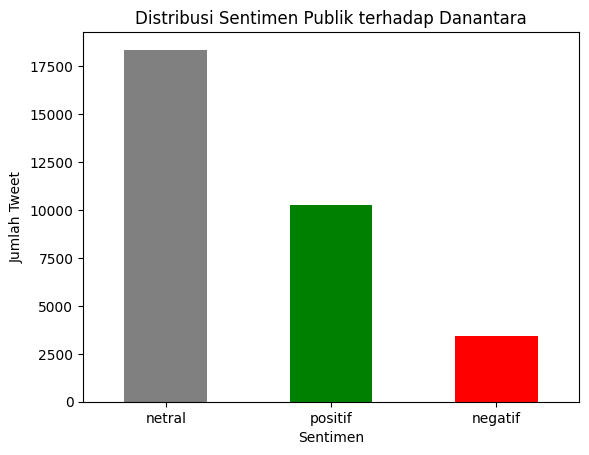

In [12]:
import matplotlib.pyplot as plt

df_id['sentimen'].value_counts().plot(kind='bar', color=['gray', 'green', 'red'])
plt.title("Distribusi Sentimen Publik terhadap Danantara")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()


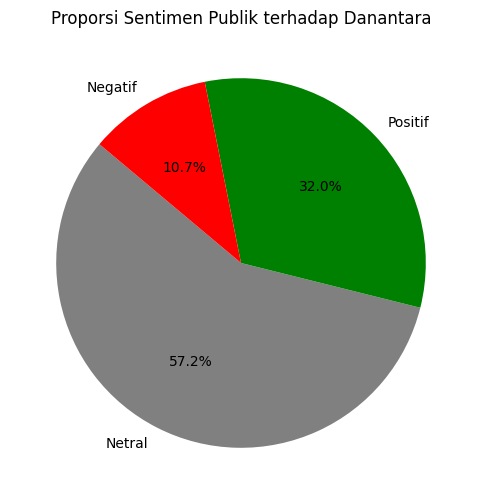

In [13]:
plt.figure(figsize=(6,6))
df_id['sentimen'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['gray', 'green', 'red'],
    labels=['Netral', 'Positif', 'Negatif'],
    startangle=140
)
plt.title("Proporsi Sentimen Publik terhadap Danantara")
plt.ylabel('')
plt.show()

In [14]:
all_words = " ".join(df_id['clean_text']).split()
common_words = Counter(all_words).most_common(10)

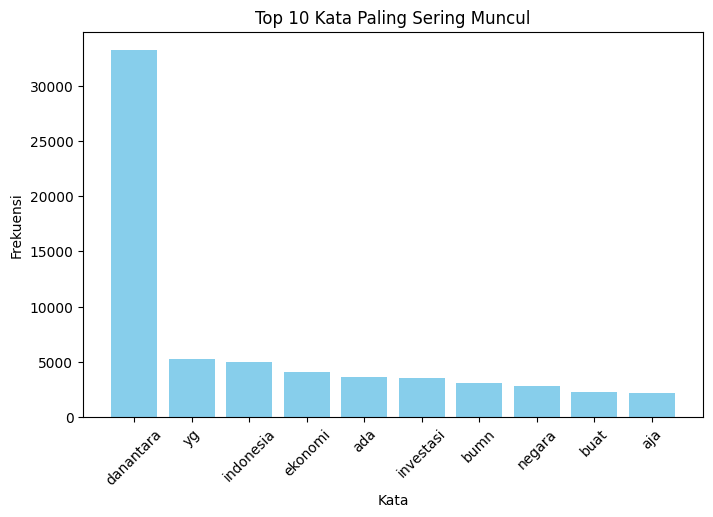

In [15]:
# Visualisasi
words, counts = zip(*common_words)
plt.figure(figsize=(8,5))
plt.bar(words, counts, color='skyblue')
plt.title("Top 10 Kata Paling Sering Muncul")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

In [16]:
sentimen_labels = ['positif', 'netral', 'negatif']
colors = ['green', 'gray', 'red']

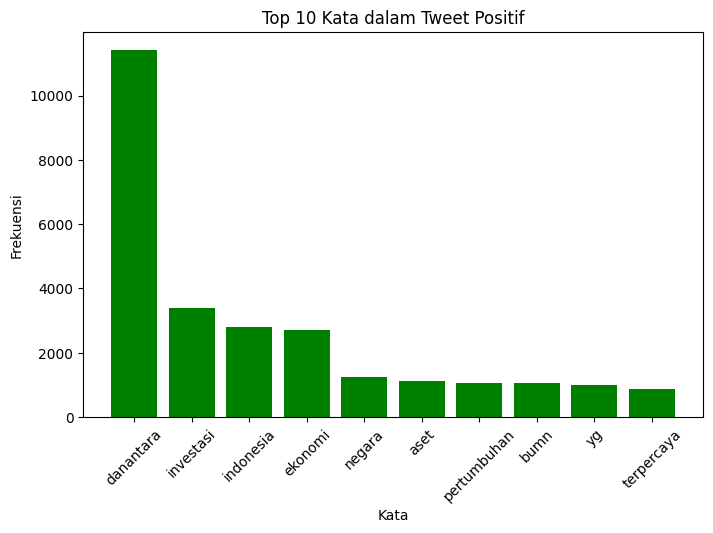

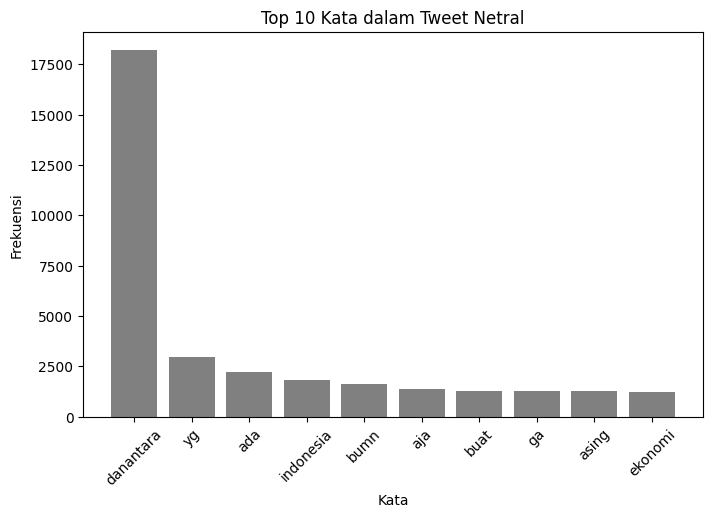

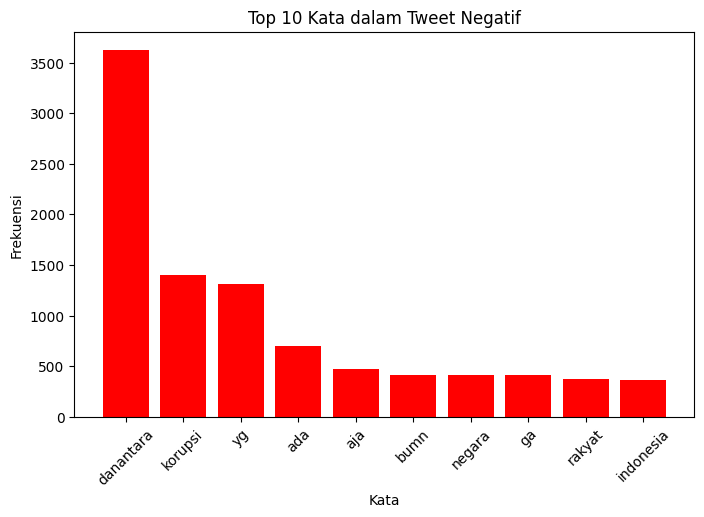

In [17]:
for sentimen, color in zip(sentimen_labels, colors):
    subset = df_id[df_id['sentimen'] == sentimen]
    words = " ".join(subset['clean_text']).split()
    common_words = Counter(words).most_common(10)
    
    if common_words:
        kata, jumlah = zip(*common_words)
        plt.figure(figsize=(8,5))
        plt.bar(kata, jumlah, color=color)
        plt.title(f"Top 10 Kata dalam Tweet {sentimen.capitalize()}")
        plt.xlabel("Kata")
        plt.ylabel("Frekuensi")
        plt.xticks(rotation=45)
        plt.show()
    else:
        print(f"Tidak ada kata untuk label sentimen '{sentimen}'.")

## Model Klasifikasi Dengan IndoBERT

In [18]:
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification,  Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
from datasets import Dataset
from sklearn.metrics import classification_report, accuracy_score
import torch

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.util

In [19]:
positive_words = [
"transparan", "akuntabel", "profesional", "kredibel", "efisien", "efektif", "inovatif", "strategis",
"sinergi", "kolaborasi", "pertumbuhan", "investasi", "optimalisasi", "modernisasi", "reformasi",
"restrukturisasi", "pengembangan", "kemajuan", "peningkatan", "stabilitas", "kepercayaan", "keberhasilan",
"sukses", "unggul", "kompetitif", "terdepan", "adaptif", "responsif", "progresif", "berkelanjutan",
"integritas", "dedikasi", "komitmen", "aspiratif", "solutif", "proaktif", "antusias", "semangat",
"optimis", "apresiasi", "penghargaan", "prestasi", "reputasi", "populer", "favorit", "elegan", "eksklusif",
"istimewa", "spesial", "unik", "menarik", "menawan", "memikat", "mempesona", "berharga", "bernilai",
"berkualitas", "terjangkau", "murah", "hemat", "irit", "praktis", "simpel", "mudah", "cepat", "tangkas",
"lincah", "gesit", "tepat", "akurat", "cerdas", "pintar", "bijak", "arif", "maju", "berkembang",
"produktif", "cemerlang", "luar biasa", "memuaskan", "optimal", "kompeten", "terampil", "handal",
"solid", "kokoh", "sejahtera", "makmur", "harmonis", "transparansi", "akuntabilitas", "kredibilitas",
"responsivitas", "fleksibilitas", "dinamis", "kreativitas", "visi", "misi", "tujuan",
"unggulan", "inspiratif", "enerjik", "positif", "cerah", "jaya", "tangguh", "visioner", "heroik",
"solusi", "cerdas", "juara", "bijaksana", "berdaya", "terpercaya", "relevan", "populer", "ikonik",
"menyala", "semarak", "melesat", "fantastis", "spekatakuler", "mengagumkan", "terbaik", "unggul",
"andal", "sehat", "mahir", "kompeten", "santun", "damai", "bersahabat", "ramah", "ceria", "menyentuh",
"tersentuh", "kekinian", "terbaru", "update", "modern", "terstruktur", "visioner", "cerdas", "ahli",
"bijaksana", "tegas", "bersinar", "kilau", "mengkilap", "apik", "keren", "solidaritas", "terlatih",
"jempolan", "brilian", "gemilang", "segar", "mencerahkan", "legendaris", "berwarna", "bercahaya",
"semarak", "riang", "ceria", "hangat", "ceria", "tenang", "nyaman", "aman", "selamat", "produktif",
"reformatif", "maju", "modern", "terdepan", "pelopor", "influencer", "influensial", "ikonik", "moderat",
"beken", "berkesan", "dikenal", "berpengaruh", "patut dicontoh", "pelayan publik", "profesionalisme",
"toleransi", "supportif", "inspirasi", "fleksibel", "unggulan", "cemerlang", "mendunia", "konsisten",
"transformatif", "adil", "berintegritas", "humanis", "moderat", "berprestasi", "superior", "kontributif",
"empati", "teladan", "intelektual", "penggerak", "produktifitas", "harmoni", "empowering", "interaktif",
"solutif", "bermanfaat", "ramah lingkungan", "lestarikan", "asri", "menghijaukan", "berpotensi",
"berpeluang", "infrastruktur", "energi positif", "berkarakter", "terampil", "kompeten", "unggul",
"dinamis", "disiplin", "bertanggung jawab", "progresif", "menyemangati", "berjaya", "penuh motivasi",
"seimbang", "sportif", "merakyat", "berbudaya", "inovator", "berkemajuan", "berpengalaman",
"berwawasan", "bermoral", "unggul", "multitalenta", "smart", "cerdas digital", "literasi tinggi",
"up to date", "bisa diandalkan", "menginspirasi", "berkapasitas", "tahan banting", "mental kuat",
"visioner muda", "berkomitmen", "peduli", "peduli sesama", "sadar sosial", "etis", "normatif",
"proporsional", "kolaboratif", "antusiasme", "sinergis", "berintegrasi", "koneksi kuat",
"mengutamakan rakyat", "pengayom", "penuh energi", "cepat tanggap", "produktifitas tinggi",
"mandiri", "konsistensi", "terpercaya publik", "menguatkan", "berkelanjutan", "resilien", "berdaya saing"
]

negative_words = [
"korupsi", "kontroversi", "inefisiensi", "ketidakjelasan", "ketidaktransparanan", "ketidakpastian",
"penyelewengan", "penyalahgunaan", "manipulasi", "monopoli", "spekulasi", "ilegal", "melanggar", "sanksi",
"denda", "penurunan", "penolakan", "pembatalan", "pemutusan", "pemecatan", "pengangguran", "kemiskinan",
"ketimpangan", "ketidakadilan", "diskriminasi", "eksploitasi", "intimidasi", "provokasi", "sabotase",
"teror", "penindasan", "penyimpangan", "pelanggaran", "penyelundupan", "pencucian uang", "penipuan",
"perampokan", "pencurian", "pembunuhan", "pengkhianatan", "penggelapan", "pengrusakan", "perusakan",
"pemalsuan", "penyesatan", "penghasutan", "pembohongan", "penistaan", "fitnah", "hoaks", "rumor", "gosip",
"skandal", "aib", "cacat", "cela", "hina", "ejek", "cemooh", "sindir", "sinis", "sarkas", "ironi", "kecewa",
"sedih", "marah", "benci", "dendam", "frustasi", "stres", "depresi", "trauma", "panik", "takut", "khawatir",
"cemas", "gelisah", "waspada", "curiga", "skeptis", "gagal", "menurun", "lemah", "ancaman", "krisis",
"konflik", "kacau", "hancur", "bangkrut", "pailit", "defisit", "inflasi", "resesi", "stagnasi",
"fraud", "amoral", "hipokrit", "kecurangan", "dugaan", "keterpurukan", "kemerosotan", "penindasan",
"kontroversial", "radikal", "provokatif", "ancam", "kebocoran", "resiko", "berbahaya", "buruk", "fatal",
"malapetaka", "bencana", "merugikan", "konspirasi", "kabur", "carut marut", "disharmoni", "parah", "celaka",
"membahayakan", "tekanan", "perseteruan", "saling serang", "ricuh", "keterbelakangan", "kriminal",
"penggelapan pajak", "penjarahan", "anarkis", "kerusuhan", "kacau balau", "demonstrasi rusuh",
"pemberontakan", "pelanggaran etika", "tabrakan", "kecelakaan", "kemacetan", "kebingungan", "salah arah",
"gagal total", "musibah", "mengerikan", "destruktif", "pesimistis", "negatif", "gelap", "buram",
"merosot", "suram", "lesu", "ambruk", "jatuh", "sengketa", "pembengkakan", "overbudget", "maladministrasi",
"cacat moral", "tidak kredibel", "penyalahgunaan wewenang", "pembohongan publik", "sensasi murahan",
"malpraktik", "imoral", "merosot drastis", "tidak sehat", "kekerasan", "kriminalitas", "buruk rupa",
"disfungsi", "malfungsi", "terbelakang", "semrawut", "polemik", "kepentingan pribadi", "korup",
"praktik haram", "degradasi", "mudhorot", "persekusi", "huru-hara", "masalah", "kesulitan", "tantangan berat",
"penindasan publik", "ancaman sosial", "disinformasi", "kejahatan digital", "hoax massal",
"penyesatan informasi", "provokasi daring", "kecurangan sistem", "kesalahan prosedur",
"diskriminatif", "serampangan", "brutal", "jahat", "kejam", "berlebihan", "menjijikan", "mengkhawatirkan",
"membingungkan", "memalukan", "parahnya", "sangat buruk", "fitnah digital", "pembajakan", "kejahatan siber",
"pencurian data", "phishing", "ransomware", "malware", "cyberbullying", "provokator online",
"ancaman digital", "data bocor", "cybercrime", "intimidasi daring", "isu sensitif", "pencemaran nama baik",
"cyber attack", "illegal access", "krisis kepercayaan", "ketidakprofesionalan", "batal proyek",
"kegagalan program", "sabotase proyek", "tindakan represif", "represif", "pendiskreditan",
"kesalahan fatal", "blunder", "penghinaan publik", "friksi", "diskriminasi sistemik", "eksploitasi digital"
]

len(positive_words), len(negative_words)

(277, 236)

In [20]:
def label_sentiment(text):
    if any(word in text for word in positive_words):
        return 2 
    elif any(word in text for word in negative_words):
        return 0  
    else:
        return 1 

df_id['label'] = df_id['clean_text'].apply(label_sentiment)

In [21]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_id['clean_text'].tolist(), df_id['label'].tolist(), test_size=0.2, stratify=df_id['label'], random_state=42)

model_name = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizer.from_pretrained(model_name)
train_encodings = tokenizer(train_texts, truncation=True, padding=True)
val_encodings = tokenizer(val_texts, truncation=True, padding=True)

c:\Users\Faiz Iqbal\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


In [22]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'label': train_labels
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'label': val_labels
})

In [23]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
from sklearn.metrics import accuracy_score, classification_report
from transformers import DataCollatorWithPadding

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {'accuracy': accuracy_score(labels, predictions)}

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [25]:
from transformers import TrainingArguments
from inspect import signature

print(signature(TrainingArguments))


(output_dir: str, overwrite_output_dir: bool = False, do_train: bool = False, do_eval: bool = False, do_predict: bool = False, evaluation_strategy: Union[transformers.trainer_utils.IntervalStrategy, str] = 'no', prediction_loss_only: bool = False, per_device_train_batch_size: int = 8, per_device_eval_batch_size: int = 8, per_gpu_train_batch_size: Optional[int] = None, per_gpu_eval_batch_size: Optional[int] = None, gradient_accumulation_steps: int = 1, eval_accumulation_steps: Optional[int] = None, eval_delay: Optional[float] = 0, learning_rate: float = 5e-05, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, max_grad_norm: float = 1.0, num_train_epochs: float = 3.0, max_steps: int = -1, lr_scheduler_type: Union[transformers.trainer_utils.SchedulerType, str] = 'linear', lr_scheduler_kwargs: Optional[Dict] = <factory>, warmup_ratio: float = 0.0, warmup_steps: int = 0, log_level: Optional[str] = 'passive', log_level_replica: Option

In [26]:
import os
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./indoBERT-sentiment",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [27]:
os.environ["WANDB_MODE"] = "disable"

training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="steps",
    eval_steps=100,  
    save_strategy="steps",
    save_steps=100,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,  
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none" 
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics, 
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

  0%|          | 50/16055 [01:22<8:54:12,  2.00s/it]

{'loss': 0.8781, 'learning_rate': 4.984428526938649e-05, 'epoch': 0.02}


  1%|          | 100/16055 [02:34<6:07:01,  1.38s/it]

{'loss': 0.671, 'learning_rate': 4.9688570538772974e-05, 'epoch': 0.03}


                                                     
  1%|          | 100/16055 [06:53<6:07:01,  1.38s/it]

...

                                                     
  4%|▍         | 700/16055 [45:54<5:46:25,  1.35s/it]

{'eval_loss': 0.3789406716823578, 'eval_accuracy': 0.9191714686185952, 'eval_runtime': 249.7084, 'eval_samples_per_second': 25.714, 'eval_steps_per_second': 3.216, 'epoch': 0.22}


  4%|▍         | 700/16055 [45:56<16:47:36,  3.94s/it]

{'train_runtime': 2756.055, 'train_samples_per_second': 46.59, 'train_steps_per_second': 5.825, 'train_loss': 0.48913169043404714, 'epoch': 0.22}


TrainOutput(global_step=700, training_loss=0.48913169043404714, metrics={'train_runtime': 2756.055, 'train_samples_per_second': 46.59, 'train_steps_per_second': 5.825, 'train_loss': 0.48913169043404714, 'epoch': 0.22})

In [28]:
eval_result = trainer.evaluate()
print("Hasil Evaluasi:", eval_result)

preds_output = trainer.predict(val_dataset)
preds = np.argmax(preds_output.predictions, axis=1)
print(classification_report(val_labels, preds, target_names=["Negatif", "Netral", "Positif"]))


100%|██████████| 803/803 [04:05<00:00,  3.27it/s]


Hasil Evaluasi: {'eval_loss': 0.36626461148262024, 'eval_accuracy': 0.9017287026942844, 'eval_runtime': 246.138, 'eval_samples_per_second': 26.087, 'eval_steps_per_second': 3.262, 'epoch': 0.22}


100%|██████████| 803/803 [04:03<00:00,  3.30it/s]

              precision    recall  f1-score   support

     Negatif       0.72      0.87      0.79       770
      Netral       0.89      0.94      0.91      2798
     Positif       0.98      0.87      0.92      2853

    accuracy                           0.90      6421
   macro avg       0.86      0.90      0.88      6421
weighted avg       0.91      0.90      0.90      6421

